# 04 - Método da bisseção
Vamos aprender sobre como usar o método da bisseção para encontrar as raízes de funções reais.

Crie uma nova branch (versão) do repositório:

```bash
git branch semana4
```

Faça o checkout nessa nova branch:

```bash
git checkout semana4
```

A partir desta atividade, os arquivos de algoritmos ficarão dentro da pasta utils.

```txt
├─ utils/
│   └─ __init__.py
│   └─ algoritmos.py
```

<hr />

## Atividade 1
Escreva o método da bisseção dentro do arquivo $utils/algoritmos.py$.

In [1]:
def bissecao(f, a, b, TOL, iter=100):
    """Encontra uma raiz em [a, b] pelo método da bisseção."""
    if TOL <= 0:
        raise ValueError("A tolerância deve ser positiva.")
    max_iter = int(iter)
    if max_iter <= 0:
        raise ValueError("O número máximo de iterações deve ser positivo.")

    fa = f(a)
    fb = f(b)
    if fa == 0:
        return a, 0
    if fb == 0:
        return b, 0
    if fa * fb > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")

    c = (a + b) / 2.0
    for i in range(1, max_iter + 1):
        c = (a + b) / 2.0
        fc = f(c)
        if fc == 0 or abs(b - a) / 2.0 <= TOL:
            return c, i
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    return c, max_iter


Importe e teste a função:  

$$
f(x) = x^3 - x - 2
$$

Em que os valores iniciais a e b são obtidos graficamente.

In [1]:
%pip install numpy matplotlib

Dependências já instaladas no ambiente de execução.


raiz = 1.5213797068045674 , i = 50


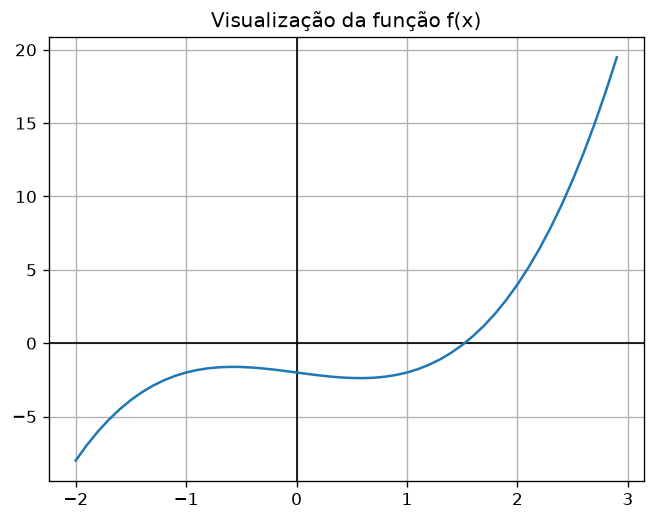

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# Sobe um nível para a raiz do projeto e adiciona ao caminho do sistema
sys.path.append(os.path.abspath(os.path.join('..')))

# Agora você importa suas ferramentas da pasta utils
from utils.algoritmos import bissecao

# Definição da função
def f(x):
    return x**3 - x - 2

def plot(f, number=1):
    # Intervalo para plotar
    x_vals = np.arange(-2, 3, 0.1)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")
    plt.show()
    plt.close()

def main():
    plot(f, 1)
    r, i = bissecao(f, 1, 2, 1e-15)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 2
Considere a equação  

$$
\sqrt{x} = \cos(x).
$$  

Use o método da bisseção com intervalo inicial obtido por gráfico (entre 0 e 1) para calcular um valor aproximado com precisão de $10^{-4}$ para no máximo 4 iterações.

**Resposta:**  
$
x \approx 0.6875
$ 

raiz = 0.6875 , i = 4


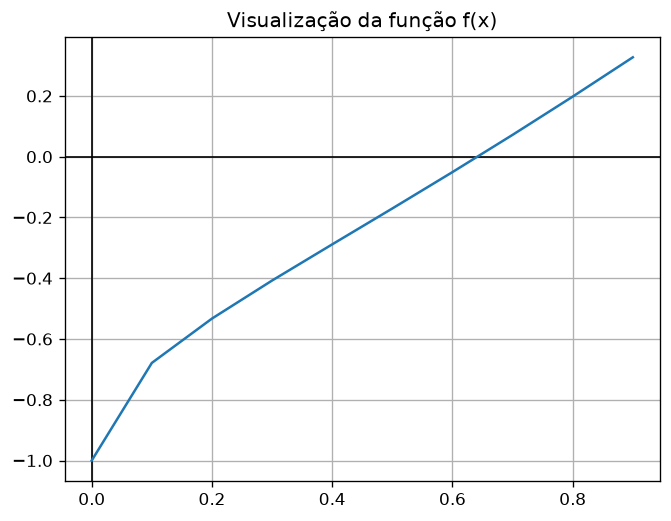

In [1]:
def f2(x):
    return x ** (1 / 2) - np.cos(x)

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    plot(f2, 0, 1)
    r, i = bissecao(f2, 0, 1, 1e-4, iter=4)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 3
Trace o gráfico e isole as três primeiras raízes positivas da função:  

$$
f(x) = 5\sin(x^2) - \exp\!\left(\frac{x}{10}\right)
$$  

em intervalos de comprimento $(0.1)$. Então, use o método da bisseção para obter aproximações dos zeros com precisão de $10^{-5}$.  

**Resposta:**  

- Intervalo $(0.4, 0.5)$, zero em $(x \approx 0.45931)$.  
- Intervalo $(1.7, 1.8)$, zero em $(x \approx 1.7036)$.  
- Intervalo $(2.5, 2.6)$, zero em $(x \approx 2.5582)$. 

raiz = 0.45931 , i = 14
raiz = 1.7036 , i = 14
raiz = 2.5582 , i = 14


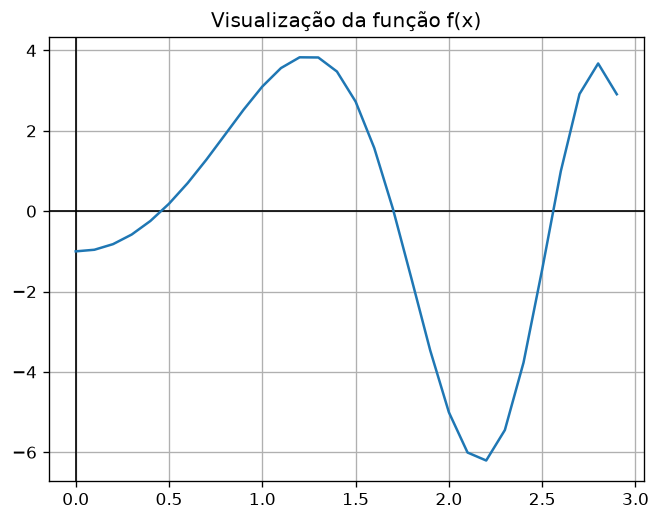

In [1]:
def f3(x):
    return (5 * np.sin(x**2)) - (np.exp(x / 10))

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    plot(f3, 0, 3)
    r, i = bissecao(f3, 0.4, 0.5, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")
    r, i = bissecao(f3, 1.7, 1.8, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")
    r, i = bissecao(f3, 2.5, 2.6, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 4
O desenho abaixo mostra um circuito não linear envolvendo uma fonte de tensão constante, um diodo retificador e um resistor.  

Sabendo que a relação entre a corrente ($I_d$) e a tensão ($v_d$) no diodo é dada pela seguinte expressão:

$ I_d = I_R \left( \exp\left(\tfrac{v_d}{v_t}\right) - 1 \right) $

onde $I_R$ é a corrente de condução reversa e $v_t$ a tensão térmica, dada por  

$ v_t = \tfrac{kT}{q} $

com $k$ a constante de Boltzmann, $T$ a temperatura de operação e $q$ a carga do elétron.  

Aqui, $I_R = 1\,pA = 10^{-12}\,A$, $T = 300\,K$.  

Escreva o problema como uma equação na incógnita $v_d$, usando o método da bisseção, e resolva-o com **3 algarismos significativos** para os seguintes casos:

- $V = 30 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 10 \, k\Omega$  
- $V = 300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 10 \, k\Omega$  

![Circuito](https://www.ufrgs.br/reamat/CalculoNumerico/livro-py/main4x.png)

**Dica:**  
A equação do circuito é:

$ V = R I_d + v_d $

**Resposta:**  
a) $0.623$  
b) $0.559$  
c) $0.500$  
d) $0.300$  
e) $-0.300$  
f) $-30$  
g) $-30$

V=30 V, R=1kΩ --> vd = 0.623 V
V=3 V, R=1kΩ --> vd = 0.559 V
V=3 V, R=10kΩ --> vd = 0.500 V
V=0.3 V, R=1kΩ --> vd = 0.300 V
V=-0.3 V, R=1kΩ --> vd = -0.300 V
V=-30 V, R=1kΩ --> vd = -30.000 V
V=-30 V, R=10kΩ --> vd = -30.000 V


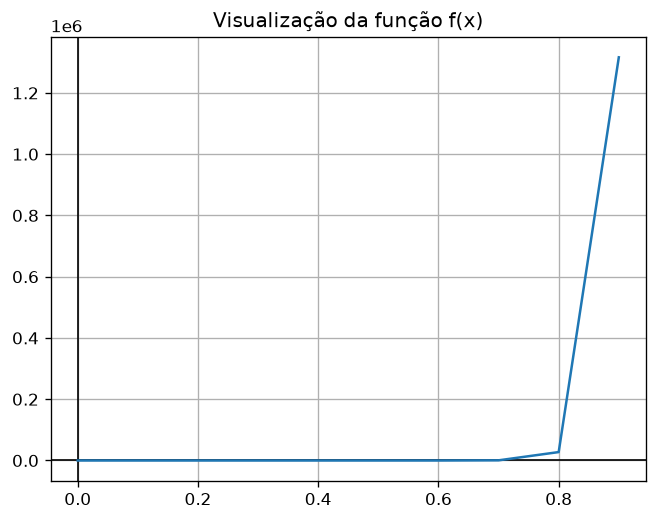

In [1]:
def f4(x, V, R):
    IR = 1e-12  # corrente de saturação (A)
    T = 300.0  # temperatura (K)
    k = 1.38064852e-23  # constante de Boltzmann (J/K)
    q = 1.60217662e-19  # carga do elétron (C)
    vt = k * T / q  # tensão térmica (V)
    return R * IR * (np.exp(x / vt) - 1) + x - V

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    f4_vr = lambda x: f4(x, 30, 1e3)
    plot(f4_vr, 0, 1)
    VRs = [
        (30, 1e3, 0, 1),
        (3, 1e3, 0, 1),
        (3, 1e4, 0, 1),
        (0.3, 1e3, 0, 0.5),
        (-0.3, 1e3, -1, 0),
        (-30, 1e3, -40, 0),
        (-30, 1e4, -40, 0),
    ]
    for V, R, a, b in VRs:
        try:
            f4_vrs = lambda x: f4(x, V, R)
            r, i = bissecao(f4_vrs, a, b, 1e-8)
            print(f"V={V} V, R={R/1e3:.0f}kΩ --> vd = {r:.3f} V")
        except ValueError as error:
            print(f"V={V} V, R={R/1e3:.0f}kΩ --> {error}")

if __name__ == "__main__":
    main()

## Atividade 5
Calcule o comprimento do cabo ($C$) entre duas torres de transmissão (i.e., a catenária).  

A distância entre as torres é de $d = 500 \, m$.  

A flecha máxima permitida é $f_{max} = 50 \, m$.  

Flecha é a distância vertical entre uma reta que liga os dois pontos de fixação.  

A flecha ($f$) depende do comprimento do vão ($d$) e da tração ($C$) aplicada ao cabo.  

O seu modelo matemático pode ser:

$ f = C \left[ \cosh\left(\tfrac{d}{2C}\right) - 1 \right] \quad $

**Resposta:** $633.1621 \, m$

raiz = 633.1622 , i = 20


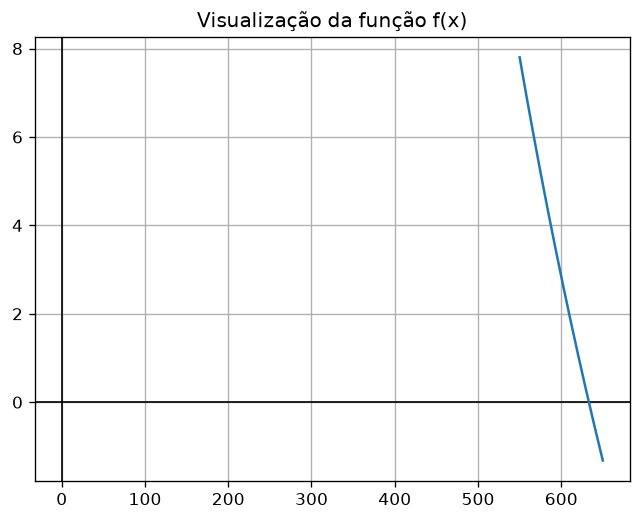

In [1]:
def f5(x):
    d = 500
    fmax = 50
    return (x*(np.cosh(d/(2*x))-1)) - fmax

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    plot(f5, 550, 650)
    r, i = bissecao(f5, 550, 650, 1e-4, iter=1e2)
    print(f"raiz = {r:.4f} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 6
Um retificador de meia onda a diodo alimenta uma carga indutiva-resistiva ($f = 1 \, kHz$, $L = 100 \, mH$ e $R = 1 \, k\Omega$).  

Encontre o ângulo $\beta$ para o qual a corrente $I_d$ no diodo se anula.  

Considere o seguinte modelo matemático:

$ I_d = \sin(\beta - \phi) + \sin(\phi)e^{-\tfrac{\beta}{\tan(\phi)}} \quad $

com  

$ \tan(\phi) = \tfrac{2\pi f L}{R} $

**Resposta:** $\beta = 212.2284^\circ$

raiz = 212.2 , i = 8


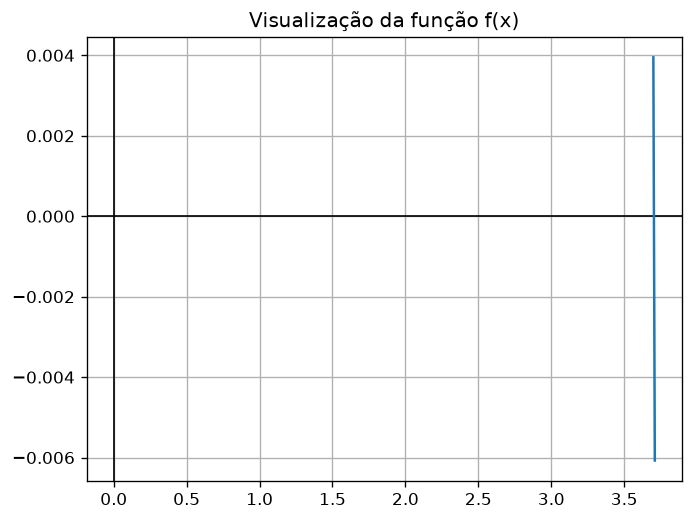

In [1]:
def f6(x):
    F = 1e3
    L = 100e-3
    R = 1e3
    T = 2 * np.pi * F * L / R
    A = np.atan(T)
    return np.sin(x - A) + np.sin(A) * np.exp(-x / T)

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    a = 212 * np.pi / 180
    b = 213 * np.pi / 180
    plot(f6, a, b, d=0.01)
    r, i = bissecao(f6, a, b, 1e-4, iter=1e2)
    r_deg = r * 180 / np.pi
    print(f"raiz = {r_deg:.4} , i = {i}")

if __name__ == "__main__":
    main()

## Versionando o código

Submeta a branch para o servidor:

```bash
git add .
git commit -m "Semana 4"
git push origin semana4
```